In [1]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
from math import comb
import matplotlib.dates as mdates
import networkx as nx
from collections import defaultdict
from networkx.algorithms.approximation.clique import large_clique_size
from itertools import combinations
import numpy as np
from networkx.algorithms.coloring import greedy_color
import random
from collections import Counter
import requests
import time
from datetime import datetime, timedelta, timezone

In [2]:
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    host="172.26.112.1",
    port=5432
)
conn.autocommit = True
cur = conn.cursor()

## Create Conflict Graphs

In [3]:
cur.execute("""
SELECT
    t.checkpoint_sequence AS checkpoint,
    oc.transaction_digest AS tx,
    oc.address AS object_address,
    c.timestamp AS timestamp
FROM transactions t
JOIN object_changes oc
  ON oc.transaction_digest = t.transaction_digest
JOIN checkpoints c
  ON c.sequence_number = t.checkpoint_sequence
WHERE oc.change_type IS NOT NULL;
""")
write_rows = cur.fetchall()

In [4]:
# graphs[checkpoint] = nx.Graph()
graphs = defaultdict(nx.Graph)

# per checkpoint: object -> list of txs that wrote it
writers_by_cp_obj = defaultdict(lambda: defaultdict(list))

# all txs per checkpoint (so isolated nodes exist)
txs_by_cp = defaultdict(set)

# checkpoint -> timestamp
timestamps_by_cp = {}

for checkpoint, tx, object_address, timestamp in write_rows:
    tx_hex = tx.hex()
    obj_hex = object_address.hex()

    txs_by_cp[checkpoint].add(tx_hex)
    writers_by_cp_obj[checkpoint][obj_hex].append(tx_hex)

    # store timestamp
    if checkpoint not in timestamps_by_cp:
        timestamps_by_cp[checkpoint] = timestamp

# Build graphs
for cp, txs in txs_by_cp.items():
    G = graphs[cp]

    # 1) add all txs as nodes (isolated txs preserved)
    G.add_nodes_from(txs)

    # 2) add edges for shared-write objects
    for writers in writers_by_cp_obj[cp].values():
        writers = list(set(writers))  # de-dup
        if len(writers) < 2:
            continue

        for u, v in combinations(writers, 2):
            G.add_edge(u, v)

# graphs[checkpoint] = NetworkX conflict graph for that checkpoint
print(f"Built {len(graphs)} checkpoint graphs")

Built 73191 checkpoint graphs


## Largest Connected Component

In [5]:
largest_cc = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        continue
    largest_cc[cp] = len(max(nx.connected_components(G), key=len))

In [6]:
df_lcc = pd.DataFrame(
    [
        (cp, lcc, timestamps_by_cp[cp])
        for cp, lcc in largest_cc.items()
    ],
    columns=["checkpoint", "largest_cc", "timestamp"]
)

df_lcc["timestamp"] = pd.to_datetime(df_lcc["timestamp"], utc=True)

## Clique Number

In [7]:
clique_sizes = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        clique_sizes[cp] = 0
        continue

    # Fast greedy heuristic for max clique size
    clique_sizes[cp] = large_clique_size(G)


In [8]:
df_clique = pd.DataFrame(
    [
        (cp, c, timestamps_by_cp[cp])
        for cp, c in clique_sizes.items()
    ],
    columns=["checkpoint", "clique_size", "timestamp"]
)

df_clique["timestamp"] = pd.to_datetime(df_clique["timestamp"], utc=True)

## Get exclude objects

In [9]:
cur.execute("""
SELECT
    t.checkpoint_sequence AS checkpoint,
    oc.transaction_digest AS tx,
    oc.address AS object_address
FROM transactions t
JOIN object_changes oc
  ON oc.transaction_digest = t.transaction_digest
WHERE oc.change_type IS NOT NULL
ORDER BY t.checkpoint_sequence, oc.transaction_digest;
""")

parent = {}
size = {}

def add(x):
    if x not in parent:
        parent[x] = x
        size[x] = 1

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra = find(a)
    rb = find(b)
    if ra == rb:
        return
    if size[ra] < size[rb]:
        ra, rb = rb, ra
    parent[rb] = ra
    size[ra] += size[rb]

def process_checkpoint(tx_to_objs, writers_by_obj):
    conflicting_txs = set()
    for writers in writers_by_obj.values():
        if len(writers) >= 2:
            conflicting_txs.update(writers)

    for tx in conflicting_txs:
        objs = tx_to_objs[tx]
        if len(objs) < 2:
            continue

        objs = list(objs)
        first = objs[0]
        add(first)
        for obj in objs[1:]:
            add(obj)
            union(first, obj)

prev_cp = None
prev_tx = None
tx_objs = set()

tx_to_objs = {}
writers_by_obj = defaultdict(set)

while True:
    batch = cur.fetchmany(100000)
    if not batch:
        break

    for cp, tx, obj in batch:
        if prev_cp is None:
            prev_cp = cp
            prev_tx = tx

        if cp != prev_cp:
            if tx_objs:
                tx_to_objs[prev_tx] = tx_objs
            process_checkpoint(tx_to_objs, writers_by_obj)

            tx_to_objs = {}
            writers_by_obj = defaultdict(set)
            tx_objs = set()
            prev_cp = cp
            prev_tx = tx

        elif tx != prev_tx:
            tx_to_objs[prev_tx] = tx_objs
            tx_objs = set()
            prev_tx = tx

        tx_objs.add(obj)
        writers_by_obj[obj].add(tx)

if tx_objs:
    tx_to_objs[prev_tx] = tx_objs
if tx_to_objs:
    process_checkpoint(tx_to_objs, writers_by_obj)

groups = defaultdict(list)
for obj in parent:
    groups[find(obj)].append(obj.hex())

groups = dict(sorted(groups.items(), key=lambda kv: len(kv[1]), reverse=True))

EXCLUDED_OBJECTS = set(next(iter(groups.values())))

## Seperate Graphs

In [10]:
deepbook_cps = {
    cp
    for cp, obj_map in writers_by_cp_obj.items()
    if EXCLUDED_OBJECTS.intersection(obj_map.keys())
}

print("DeepBook checkpoints:", len(deepbook_cps))

DeepBook checkpoints: 63898


In [11]:
graphs_db_full = {
    cp: graphs[cp]
    for cp in deepbook_cps
    if cp in graphs
}

graphs_db_edge_filtered = {}

for cp in deepbook_cps:
    Gf = graphs[cp].copy()

    # only iterate objects that actually exist in this checkpoint
    relevant_objs = EXCLUDED_OBJECTS.intersection(
        writers_by_cp_obj[cp].keys()
    )

    edges_to_remove = set()

    for obj in relevant_objs:
        writers = list(set(writers_by_cp_obj[cp][obj]))

        if len(writers) < 2:
            continue

        edges_to_remove.update(
            (writers[i], writers[j])
            for i in range(len(writers))
            for j in range(i + 1, len(writers))
        )

    Gf.remove_edges_from(edges_to_remove)

    graphs_db_edge_filtered[cp] = Gf

In [12]:

cur.execute("""
    SELECT
        t.checkpoint_sequence AS checkpoint,
        t.gas_used,
        c.timestamp
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
    WHERE t.checkpoint_sequence = ANY(%s)
""", (list(deepbook_cps),))

rows = cur.fetchall()

df_tx_gas_db = pd.DataFrame(rows, columns=["checkpoint", "gas_used", "timestamp"])

df_tx_gas_db["checkpoint"] = df_tx_gas_db["checkpoint"].astype(int)
df_tx_gas_db["gas_used"] = pd.to_numeric(df_tx_gas_db["gas_used"], errors="coerce")
df_tx_gas_db["timestamp"] = pd.to_datetime(df_tx_gas_db["timestamp"], utc=True)

df_block_db = (
    df_tx_gas_db
    .groupby("checkpoint")
    .agg(
        block_gas=("gas_used", "sum"),
        max_tx_gas=("gas_used", "max"),
        timestamp=("timestamp", "first"),
    )
    .reset_index()
)


In [13]:
# ---------- 1) prepare basics (DEEPBOOK CHECKPOINTS) ----------

df_block_db["checkpoint"] = df_block_db["checkpoint"].astype(int)
df_block_db["timestamp"] = pd.to_datetime(df_block_db["timestamp"], utc=True)

df_lcc["checkpoint"] = df_lcc["checkpoint"].astype(int)
df_clique["checkpoint"] = df_clique["checkpoint"].astype(int)

df_tx_gas_db["checkpoint"] = df_tx_gas_db["checkpoint"].astype(int)
df_tx_gas_db["gas_used"] = pd.to_numeric(df_tx_gas_db["gas_used"], errors="coerce")

# tx count per checkpoint (deepbook cps)
df_tx_count_db = (
    df_tx_gas_db
    .groupby("checkpoint")
    .size()
    .rename("tx_count")
    .reset_index()
)

# ---------- 2) merge everything (deepbook cps) ----------

df_db = (
    df_block_db
    .merge(df_lcc, on="checkpoint", how="inner")
    .merge(df_clique, on="checkpoint", how="inner")
    .merge(df_tx_count_db, on="checkpoint", how="inner")
)

# ---------- 3) approximate CC / clique gas (deepbook cps) ----------

df_db["avg_tx_gas"] = df_db["block_gas"] / df_db["tx_count"]
df_db["cc_gas"] = df_db["largest_cc"] * df_db["avg_tx_gas"]
df_db["clique_gas"] = df_db["clique_size"] * df_db["avg_tx_gas"]

# ---------- 4) daily aggregation + 95% CI (deepbook cps) ----------

metrics = {
    "block_gas": "block_gas",
    "cc_gas": "cc_gas",
    "clique_gas": "clique_gas",
    "max_tx_gas": "max_tx_gas",
}

df_gas_daily_db = (
    df_db
    .assign(day=df_db["timestamp"].dt.date)
    .groupby("day")[list(metrics.values())]
    .agg(["mean", "std", "count"])
)

# flatten columns
df_gas_daily_db.columns = ["_".join(c) for c in df_gas_daily_db.columns]
df_gas_daily_db = df_gas_daily_db.reset_index()

# compute 95% CI
for m in metrics.values():
    df_gas_daily_db[f"{m}_ci95"] = (
        1.96 * df_gas_daily_db[f"{m}_std"] / np.sqrt(df_gas_daily_db[f"{m}_count"])
    )

df_gas_daily_db["day"] = pd.to_datetime(df_gas_daily_db["day"])

# numeric safety
cols = [c for c in df_gas_daily_db.columns if c != "day"]
df_gas_daily_db[cols] = df_gas_daily_db[cols].astype(float)

# optional cleanup
df_gas_daily_db = df_gas_daily_db.dropna(
    subset=[f"{m}_mean" for m in metrics.values()]
)


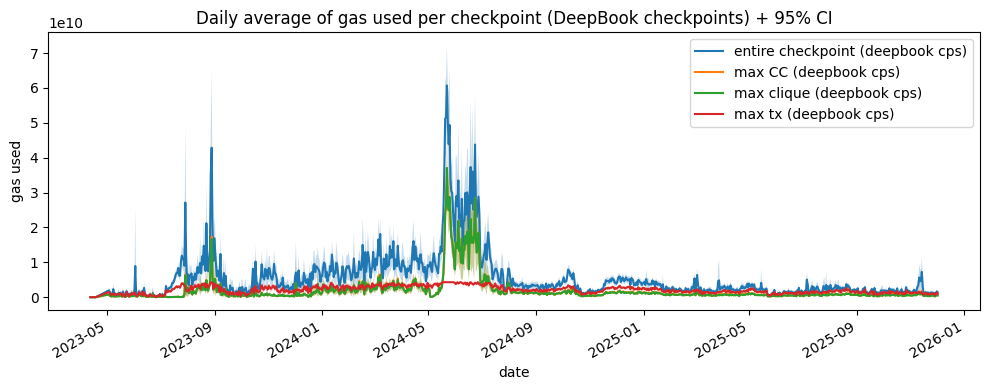

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

def plot_ci(x, mean, ci, label):
    ax.plot(x, mean, label=label)
    ax.fill_between(
        x,
        (mean - ci).clip(lower=0),
        mean + ci,
        alpha=0.25
    )

x = df_gas_daily_db["day"]

plot_ci(x, df_gas_daily_db["block_gas_mean"],  df_gas_daily_db["block_gas_ci95"],  "entire checkpoint (deepbook cps)")
plot_ci(x, df_gas_daily_db["cc_gas_mean"],     df_gas_daily_db["cc_gas_ci95"],     "max CC (deepbook cps)")
plot_ci(x, df_gas_daily_db["clique_gas_mean"], df_gas_daily_db["clique_gas_ci95"], "max clique (deepbook cps)")
plot_ci(x, df_gas_daily_db["max_tx_gas_mean"], df_gas_daily_db["max_tx_gas_ci95"], "max tx (deepbook cps)")

ax.set_ylabel("gas used")
ax.set_xlabel("date")
ax.set_title("Daily average of gas used per checkpoint (DeepBook checkpoints) + 95% CI")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()


In [15]:
# ---------- build df_speedup_daily_db ----------

df_speedup_daily_db = pd.DataFrame()
df_speedup_daily_db["day"] = df_gas_daily_db["day"]

# lower bound: total / max CC
df_speedup_daily_db["speedup_lb"] = (
    df_gas_daily_db["block_gas_mean"] / df_gas_daily_db["cc_gas_mean"]
)

# upper bound: total / max clique
df_speedup_daily_db["speedup_ub"] = (
    df_gas_daily_db["block_gas_mean"] / df_gas_daily_db["clique_gas_mean"]
)

# ---------- 95% CI via delta method ----------

def ratio_ci(mean_a, ci_a, mean_b, ci_b):
    ratio = mean_a / mean_b
    rel_err = np.sqrt((ci_a / mean_a) ** 2 + (ci_b / mean_b) ** 2)
    return ratio * rel_err

df_speedup_daily_db["speedup_lb_ci95"] = ratio_ci(
    df_gas_daily_db["block_gas_mean"],
    df_gas_daily_db["block_gas_ci95"],
    df_gas_daily_db["cc_gas_mean"],
    df_gas_daily_db["cc_gas_ci95"],
)

df_speedup_daily_db["speedup_ub_ci95"] = ratio_ci(
    df_gas_daily_db["block_gas_mean"],
    df_gas_daily_db["block_gas_ci95"],
    df_gas_daily_db["clique_gas_mean"],
    df_gas_daily_db["clique_gas_ci95"],
)

# numeric safety
cols = ["speedup_lb", "speedup_lb_ci95", "speedup_ub", "speedup_ub_ci95"]
df_speedup_daily_db[cols] = df_speedup_daily_db[cols].astype(float)

# optional cleanup
df_speedup_daily_db = df_speedup_daily_db.replace([np.inf, -np.inf], np.nan)
df_speedup_daily_db = df_speedup_daily_db.dropna(subset=cols)


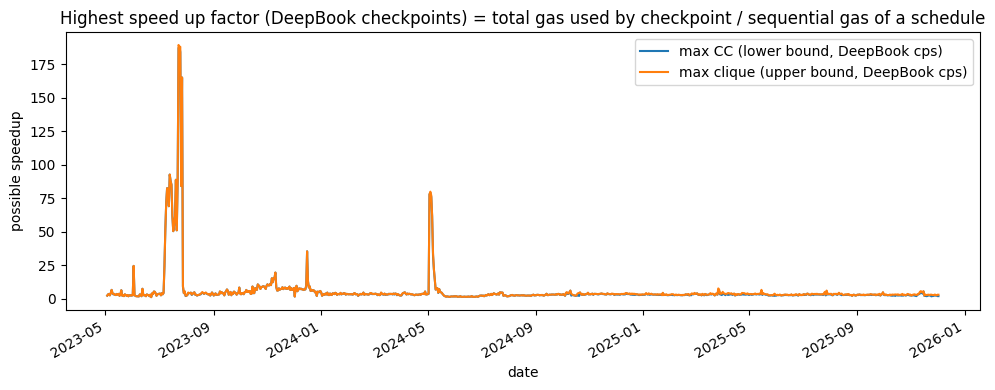

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

# lower bound (max CC) — DeepBook checkpoints
ax.plot(
    df_speedup_daily_db["day"],
    df_speedup_daily_db["speedup_lb"],
    label="max CC (lower bound, DeepBook cps)"
)
"""ax.fill_between(
    df_speedup_daily_db["day"],
    (df_speedup_daily_db["speedup_lb"] - df_speedup_daily_db["speedup_lb_ci95"]).clip(lower=0),
    df_speedup_daily_db["speedup_lb"] + df_speedup_daily_db["speedup_lb_ci95"],
    alpha=0.25
)"""

# upper bound (max clique) — DeepBook checkpoints
ax.plot(
    df_speedup_daily_db["day"],
    df_speedup_daily_db["speedup_ub"],
    label="max clique (upper bound, DeepBook cps)"
)
"""ax.fill_between(
    df_speedup_daily_db["day"],
    (df_speedup_daily_db["speedup_ub"] - df_speedup_daily_db["speedup_ub_ci95"]).clip(lower=0),
    df_speedup_daily_db["speedup_ub"] + df_speedup_daily_db["speedup_ub_ci95"],
    alpha=0.25
)"""

ax.set_ylabel("possible speedup")
ax.set_xlabel("date")
ax.set_title(
    "Highest speed up factor (DeepBook checkpoints) = total gas used by checkpoint / sequential gas of a schedule"
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()


In [17]:
largest_cc_filtered = {}

for cp, G_filtered in graphs_db_edge_filtered.items():
    if G_filtered.number_of_nodes() == 0:
        continue
    largest_cc_filtered[cp] = len(max(nx.connected_components(G_filtered), key=len))

df_lcc_filtered = pd.DataFrame(
    [
        (cp, lcc, timestamps_by_cp.get(cp))
        for cp, lcc in largest_cc_filtered.items()
        if timestamps_by_cp.get(cp) is not None
    ],
    columns=["checkpoint", "largest_cc", "timestamp"]
)

df_lcc_filtered["timestamp"] = pd.to_datetime(df_lcc_filtered["timestamp"], utc=True)
df_lcc_filtered = df_lcc_filtered.sort_values("timestamp")

In [18]:
clique_sizes_filtered = {}

for cp, G_filtered in graphs_db_edge_filtered.items():
    if G_filtered.number_of_nodes() == 0:
        clique_sizes_filtered[cp] = 0
        continue

    clique_sizes_filtered[cp] = large_clique_size(G_filtered)

df_clique_filtered = pd.DataFrame(
    [
        (cp, c, timestamps_by_cp.get(cp))
        for cp, c in clique_sizes_filtered.items()
        if timestamps_by_cp.get(cp) is not None
    ],
    columns=["checkpoint", "clique_size", "timestamp"]
)

df_clique_filtered["timestamp"] = pd.to_datetime(
    df_clique_filtered["timestamp"], utc=True
)
df_clique_filtered = df_clique_filtered.sort_values("timestamp")

In [19]:
# =========================================================
# Build df_speedup_daily_db_filtered (DeepBook edge-removed)
# =========================================================

# ---- tx count for DeepBook checkpoints (same txs; edge removal doesn't change tx set)
df_tx_count_db = (
    df_tx_gas_db
    .groupby("checkpoint")
    .size()
    .rename("tx_count")
    .reset_index()
)

# ---- build df using edge-filtered clique + original LCC (DeepBook cps)
# (edge removal affects CC/clique metrics, not gas totals)

df_db_filtered = (
    df_block_db
    .merge(df_lcc_filtered, on="checkpoint", how="inner")      # LCC after edge removal
    .merge(df_clique_filtered, on="checkpoint", how="inner")  # clique after edge removal
    .merge(df_tx_count_db, on="checkpoint", how="inner")
)

# ---- recompute derived gas metrics
df_db_filtered["avg_tx_gas"] = df_db_filtered["block_gas"] / df_db_filtered["tx_count"]
df_db_filtered["cc_gas"] = df_db_filtered["largest_cc"] * df_db_filtered["avg_tx_gas"]
df_db_filtered["clique_gas"] = df_db_filtered["clique_size"] * df_db_filtered["avg_tx_gas"]

# ---- daily aggregation
metrics = {
    "block_gas": "block_gas",
    "cc_gas": "cc_gas",
    "clique_gas": "clique_gas",
    "max_tx_gas": "max_tx_gas",
}

df_gas_daily_db_filtered = (
    df_db_filtered
    .assign(day=df_db_filtered["timestamp"].dt.date)
    .groupby("day")[list(metrics.values())]
    .agg(["mean", "std", "count"])
)

df_gas_daily_db_filtered.columns = ["_".join(c) for c in df_gas_daily_db_filtered.columns]
df_gas_daily_db_filtered = df_gas_daily_db_filtered.reset_index()

# ---- CI
for m in metrics.values():
    df_gas_daily_db_filtered[f"{m}_ci95"] = (
        1.96 * df_gas_daily_db_filtered[f"{m}_std"] /
        np.sqrt(df_gas_daily_db_filtered[f"{m}_count"])
    )

df_gas_daily_db_filtered["day"] = pd.to_datetime(df_gas_daily_db_filtered["day"])

# ---- speedup bounds
df_speedup_daily_db_filtered = pd.DataFrame()
df_speedup_daily_db_filtered["day"] = df_gas_daily_db_filtered["day"]

df_speedup_daily_db_filtered["speedup_lb"] = (
    df_gas_daily_db_filtered["block_gas_mean"] /
    df_gas_daily_db_filtered["cc_gas_mean"]
)

df_speedup_daily_db_filtered["speedup_ub"] = (
    df_gas_daily_db_filtered["block_gas_mean"] /
    df_gas_daily_db_filtered["clique_gas_mean"]
)

def ratio_ci(mean_a, ci_a, mean_b, ci_b):
    ratio = mean_a / mean_b
    rel_err = np.sqrt((ci_a / mean_a) ** 2 + (ci_b / mean_b) ** 2)
    return ratio * rel_err

df_speedup_daily_db_filtered["speedup_lb_ci95"] = ratio_ci(
    df_gas_daily_db_filtered["block_gas_mean"],
    df_gas_daily_db_filtered["block_gas_ci95"],
    df_gas_daily_db_filtered["cc_gas_mean"],
    df_gas_daily_db_filtered["cc_gas_ci95"],
)

df_speedup_daily_db_filtered["speedup_ub_ci95"] = ratio_ci(
    df_gas_daily_db_filtered["block_gas_mean"],
    df_gas_daily_db_filtered["block_gas_ci95"],
    df_gas_daily_db_filtered["clique_gas_mean"],
    df_gas_daily_db_filtered["clique_gas_ci95"],
)

# ---- cleanup
cols = ["speedup_lb", "speedup_lb_ci95", "speedup_ub", "speedup_ub_ci95"]
df_speedup_daily_db_filtered[cols] = df_speedup_daily_db_filtered[cols].astype(float)
df_speedup_daily_db_filtered = df_speedup_daily_db_filtered.replace([np.inf, -np.inf], np.nan)
df_speedup_daily_db_filtered = df_speedup_daily_db_filtered.dropna(subset=cols)


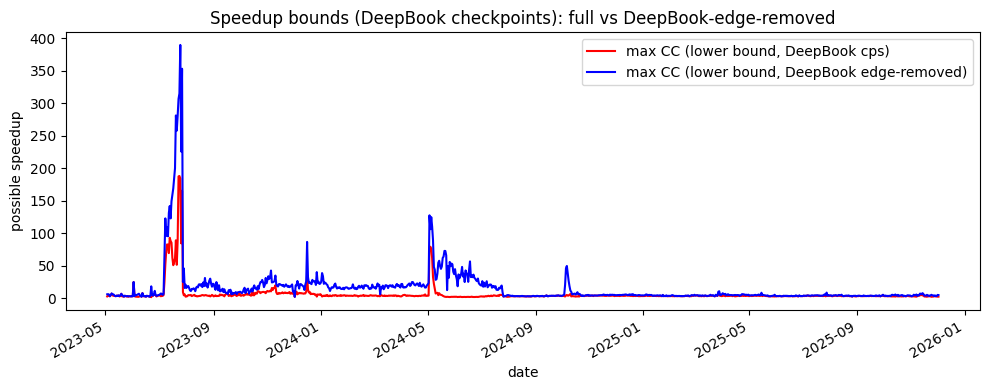

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))

# --- lower bound comparison (DeepBook checkpoints) ---
ax.plot(
    df_speedup_daily_db["day"],
    df_speedup_daily_db["speedup_lb"],
    label="max CC (lower bound, DeepBook cps)",
    color="red"
)

ax.plot(
    df_speedup_daily_db_filtered["day"],
    df_speedup_daily_db_filtered["speedup_lb"],
    label="max CC (lower bound, DeepBook edge-removed)",
    color="blue"
)

ax.set_ylabel("possible speedup")
ax.set_xlabel("date")
ax.set_title(
    "Speedup bounds (DeepBook checkpoints): full vs DeepBook-edge-removed"
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()


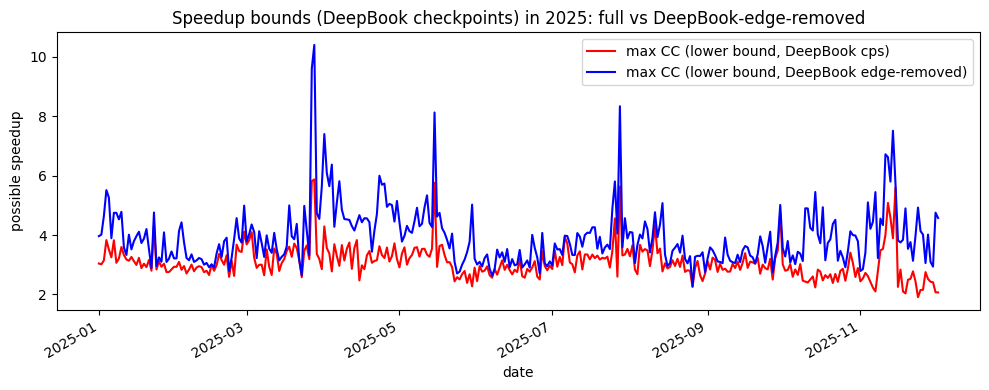

In [21]:
# --- filter to 2025 ---
mask_full = df_speedup_daily_db["day"].dt.year == 2025
mask_filt = df_speedup_daily_db_filtered["day"].dt.year == 2025

df_speedup_2025 = df_speedup_daily_db[mask_full]
df_speedup_filtered_2025 = df_speedup_daily_db_filtered[mask_filt]

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 4))

# lower bound
ax.plot(
    df_speedup_2025["day"],
    df_speedup_2025["speedup_lb"],
    label="max CC (lower bound, DeepBook cps)",
    color="red"
)

ax.plot(
    df_speedup_filtered_2025["day"],
    df_speedup_filtered_2025["speedup_lb"],
    label="max CC (lower bound, DeepBook edge-removed)",
    color="blue"
)


ax.set_ylabel("possible speedup")
ax.set_xlabel("date")
ax.set_title("Speedup bounds (DeepBook checkpoints) in 2025: full vs DeepBook-edge-removed")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()
